### 1.0 Combine Dataset - to execute separately from Steps 2-4

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
import os
import pandas as pd

folder_path = r"D:\fypadpm\dataset\CSECICIDS2018\Processed Traffic Data for ML Algorithms"
print("Folder exists:", os.path.isdir(folder_path))
print("Folder path:", folder_path)

csv_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".csv")]
print("CSV count:", len(csv_files))

df_list = []
for f in csv_files:
    file_path = os.path.join(folder_path, f)
    print("Reading:", f)
    df_list.append(pd.read_csv(file_path, encoding="latin1", low_memory=False))

df_combined = pd.concat(df_list, ignore_index=True, sort=False)

output_file_path = r"D:\fypadpm\dataset\CSECICIDS2018\combined_data.csv"
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)
df_combined.to_csv(output_file_path, index=False)

print("Saved to:", output_file_path)
print("Combined shape:", df_combined.shape)



Folder exists: True
Folder path: D:\fypadpm\dataset\CSECICIDS2018\Processed Traffic Data for ML Algorithms
CSV count: 10
Reading: Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
Reading: Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
Reading: Friday-23-02-2018_TrafficForML_CICFlowMeter.csv
Reading: Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv
Reading: Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv
Reading: Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv
Reading: Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv
Reading: Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv
Reading: Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv
Reading: Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv
Saved to: D:\fypadpm\dataset\CSECICIDS2018\combined_data.csv
Combined shape: (16233002, 84)


### 2.0 Data Exploration

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [11]:
import os
path = r"D:\fypadpm\dataset\CSECICIDS2018\combined_data.csv"
print("Exists?", os.path.exists(path))
print("Size (MB):", os.path.getsize(path)/1024/1024)


Exists? True
Size (MB): 7007.057010650635


In [12]:
#df_combined = pd.read_csv(r"D:\r6g\proj1\cicids2018\combined_data.csv", low_memory=False)


In [1]:
import pandas as pd
import numpy as np

path = r"D:\fypadpm\dataset\CSECICIDS2018\combined_data.csv"

chunks = []
for chunk in pd.read_csv(path, encoding="latin1", low_memory=False, 
                          quoting=3, chunksize=1000_000):
    chunks.append(chunk)

df_combined = pd.concat(chunks, ignore_index=True)
del chunks
print(df_combined.shape)

(16233002, 84)


In [2]:
print(df_combined.shape)
print(df_combined.info())

(16233002, 84)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16233002 entries, 0 to 16233001
Data columns (total 84 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Dst Port           object 
 1   Protocol           object 
 2   Timestamp          object 
 3   Flow Duration      object 
 4   Tot Fwd Pkts       object 
 5   Tot Bwd Pkts       object 
 6   TotLen Fwd Pkts    object 
 7   TotLen Bwd Pkts    object 
 8   Fwd Pkt Len Max    object 
 9   Fwd Pkt Len Min    object 
 10  Fwd Pkt Len Mean   object 
 11  Fwd Pkt Len Std    object 
 12  Bwd Pkt Len Max    object 
 13  Bwd Pkt Len Min    object 
 14  Bwd Pkt Len Mean   object 
 15  Bwd Pkt Len Std    object 
 16  Flow Byts/s        object 
 17  Flow Pkts/s        object 
 18  Flow IAT Mean      object 
 19  Flow IAT Std       object 
 20  Flow IAT Max       object 
 21  Flow IAT Min       object 
 22  Fwd IAT Tot        object 
 23  Fwd IAT Mean       object 
 24  Fwd IAT Std        object 
 25  F

In [3]:
num_rows, num_cols = df_combined.shape
print("Number of rows:", num_rows)
print("Number of columns:", num_cols)

Number of rows: 16233002
Number of columns: 84


In [4]:
pd.set_option('display.max_columns', None)
display(df_combined)

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Flow ID,Src IP,Src Port,Dst IP
0,443,6,02/03/2018 08:47:38,141385,9,7,553,3773.0,202,0,61.444444,87.534438,1460,0,539.0,655.432936,30597.30523,113.166178,9425.666667,19069.11685,73403.0,1.0,141385.0,17673.125,23965.32327,73403.0,22.0,51417.0,8569.5,13036.89082,31525.0,1.0,0,0,0,0,192,152,63.655975,49.510203,0,1460,254.470588,474.712955,225352.3897,0,0,1,1,0,0,0,1,0,270.375,61.444444,539.0,0,0,0,0,0,0,9,553,7,3773,8192,119,4,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,NaN,NaN,NaN,NaN
1,49684,6,02/03/2018 08:47:38,281,2,1,38,0.0,38,0,19.0,26.870058,0,0,0.0,0.0,135231.3167,10676.15658,140.5,174.655375,264.0,17.0,281.0,281.0,0.0,281.0,281.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,40,20,7117.437722,3558.718861,0,38,19.0,21.93931,481.333333,0,1,0,0,1,0,0,0,0,25.333333,19.0,0.0,0,0,0,0,0,0,2,38,1,0,123,0,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,NaN,NaN,NaN,NaN
2,443,6,02/03/2018 08:47:40,279824,11,15,1086,10527.0,385,0,98.727273,129.392497,1460,0,701.8,636.314186,41501.0864,92.915547,11192.96,24379.44834,112589.0,1.0,279728.0,27972.8,36167.74032,112589.0,94.0,258924.0,18494.57143,36356.50372,133669.0,1.0,0,0,0,0,232,312,39.310424,53.605123,0,1460,430.111111,566.234209,320621.1795,0,0,1,1,0,0,0,1,1,446.653846,98.727273,701.8,0,0,0,0,0,0,11,1086,15,10527,8192,1047,5,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,NaN,NaN,NaN,NaN
3,443,6,02/03/2018 08:47:40,132,2,0,0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,15151.51515,132.0,0.0,132.0,132.0,132.0,132.0,0.0,132.0,132.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,40,0,15151.51515,0.0,0,0,0.0,0.0,0.0,0,0,0,0,1,0,0,0,0,0.0,0.0,0.0,0,0,0,0,0,0,2,0,0,0,256,-1,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,NaN,NaN,NaN,NaN
4,443,6,02/03/2018 08:47:41,274016,9,13,1285,6141.0,517,0,142.777778,183.887722,1460,0,472.384615,611.180489,27100.60726,80.287282,13048.38095,26311.62703,114077.0,1.0,273946.0,34243.25,37996.56546,114077.0,201.0,252994.0,21082.83333,39075.73819,135611.0,1.0,0,0,0,0,192,272,32.844797,47.442485,0,1460,322.869565,497.254764,247262.3004,0,0,1,1,0,0,0,1,1,337.545455,142.777778,472.384615,0,0,0,0,0,0,9,1285,13,6141,8192,1047,5,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16232997,23,6,28/02/2018 11:59:12,3,1,1,0,0,0,0,0,0,0,0,0,0,0,666666.6667,3,0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,24,20,333333.3333,333333.3333,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,1024,0,0,24,0,0,0,0,0,0,0,0,Infilteration,NaN,NaN,NaN,NaN
16232998,425,6,28/02/2018 10:50:04,2,1,1,0,0,0,0,0,0,0,0,0,0,0,1000000,2,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,24,20,500000,500000,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,1024,0,0,24,0,0,0

In [5]:
df_combined.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [6]:
df_combined['Label'].unique()

array(['Benign', 'Bot', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Hulk',
       'Label', 'Brute Force -Web', 'Brute Force -XSS', 'SQL Injection',
       'DDoS attacks-LOIC-HTTP', 'Infilteration', 'DoS attacks-GoldenEye',
       'DoS attacks-Slowloris', 'FTP-BruteForce', 'SSH-Bruteforce',
       'DDOS attack-LOIC-UDP', 'DDOS attack-HOIC'], dtype=object)

In [7]:
print(df_combined.nunique())

Dst Port          122568
Protocol               7
Timestamp         272380
Flow Duration    5474645
Tot Fwd Pkts        6335
                  ...   
Label                 16
Flow ID          5030830
Src IP             31291
Src Port           64898
Dst IP             27076
Length: 84, dtype: int64


In [8]:
columns_zero = []

for col in df_combined.columns:
    unique_values = df_combined[col].unique()
    if set(unique_values) == {0, '0'}:
        columns_zero.append(col)

print("Columns with only 0':", columns_zero)

Columns with only 0': []


In [9]:
missing_cols = df_combined.columns[df_combined.isnull().any()]
print("Columns with missing values:")
print(missing_cols.tolist())

Columns with missing values:
['Flow Byts/s', 'Flow ID', 'Src IP', 'Src Port', 'Dst IP']


In [10]:
missing_counts = df_combined.isnull().sum()
print("Missing value count per column:")
print(missing_counts[missing_counts > 0])

Missing value count per column:
Flow Byts/s      59721
Flow ID        8284254
Src IP         8284254
Src Port       8284254
Dst IP         8284254
dtype: int64


In [11]:
missing_percent = (df_combined.isnull().sum() / len(df_combined)) * 100
print("Missing value percentage per column:")
print(missing_percent[missing_percent > 0])

Missing value percentage per column:
Flow Byts/s     0.367899
Flow ID        51.033407
Src IP         51.033407
Src Port       51.033407
Dst IP         51.033407
dtype: float64


#### Data Distribution of Label

In [12]:
df_combined['Label'].unique()

array(['Benign', 'Bot', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Hulk',
       'Label', 'Brute Force -Web', 'Brute Force -XSS', 'SQL Injection',
       'DDoS attacks-LOIC-HTTP', 'Infilteration', 'DoS attacks-GoldenEye',
       'DoS attacks-Slowloris', 'FTP-BruteForce', 'SSH-Bruteforce',
       'DDOS attack-LOIC-UDP', 'DDOS attack-HOIC'], dtype=object)

Class Distribution:
Label
Benign                      13484708
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Label                             59
Name: count, dtype: int64


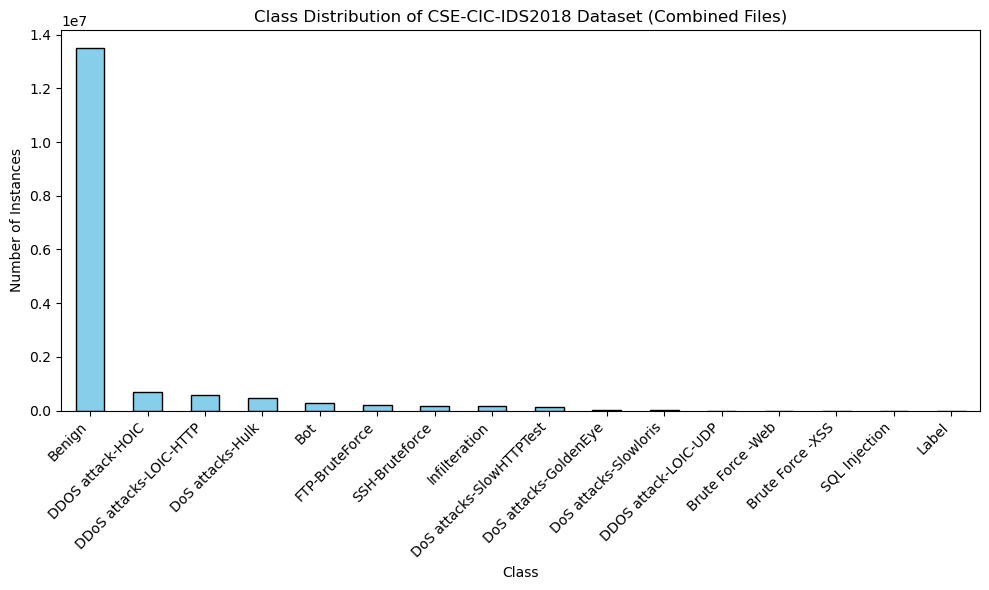

In [15]:
# Analyze class distribution of Label
class_column = 'Label'
class_counts = df_combined[class_column].value_counts()

print("Class Distribution:")
print(class_counts)

plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Class Distribution of CSE-CIC-IDS2018 Dataset (Combined Files)")
plt.xlabel("Class")
plt.ylabel("Number of Instances")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Class Distribution (excluding benign):
Label
DDOS attack-HOIC            686012
DDoS attacks-LOIC-HTTP      576191
DoS attacks-Hulk            461912
Bot                         286191
FTP-BruteForce              193360
SSH-Bruteforce              187589
Infilteration               161934
DoS attacks-SlowHTTPTest    139890
DoS attacks-GoldenEye        41508
DoS attacks-Slowloris        10990
DDOS attack-LOIC-UDP          1730
Brute Force -Web               611
Brute Force -XSS               230
SQL Injection                   87
Label                           59
Name: count, dtype: int64


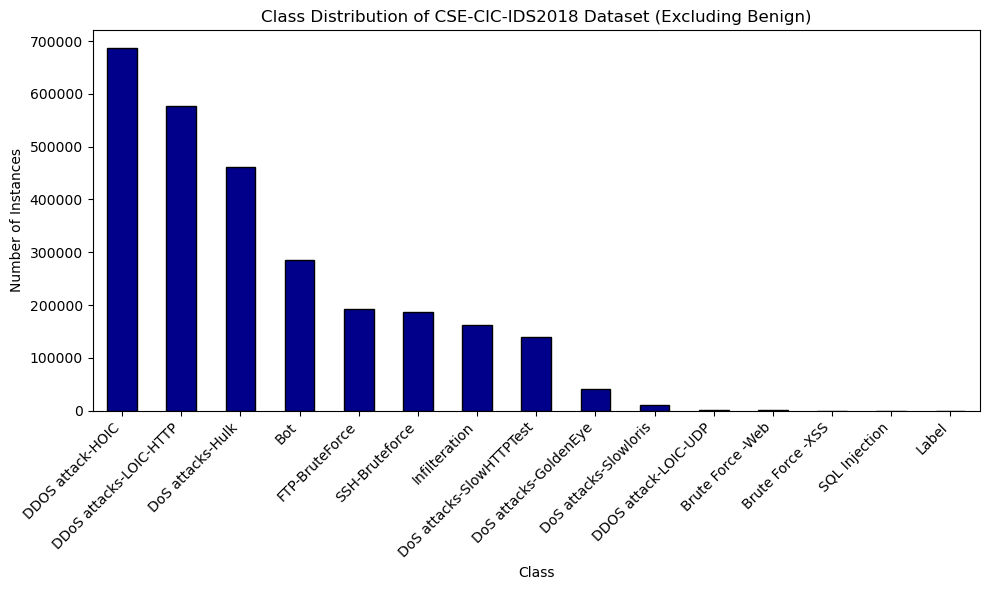

In [16]:
# Analyze class distribution - excluding 'benign'
class_column = 'Label'
filtered_data = df_combined[df_combined[class_column] != 'Benign']

class_counts = filtered_data[class_column].value_counts()

print("Class Distribution (excluding benign):")
print(class_counts)

plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar', color='darkblue', edgecolor='black')
plt.title("Class Distribution of CSE-CIC-IDS2018 Dataset (Excluding Benign)")
plt.xlabel("Class")
plt.ylabel("Number of Instances")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

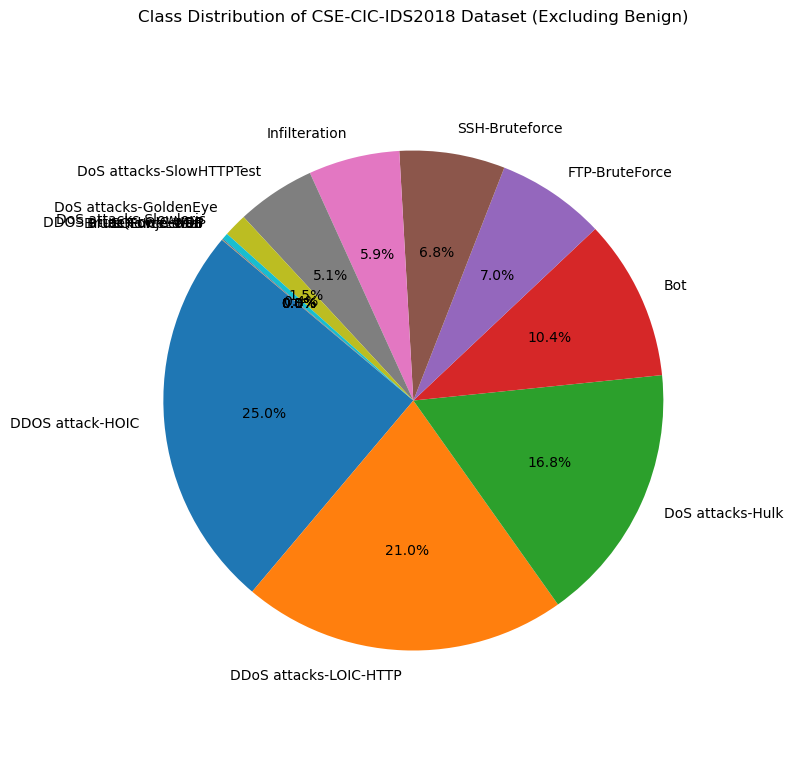

In [17]:
# Analyze class distribution (Pie Chart) - excluding 'benign'
class_column = 'Label'
filtered_data = df_combined[df_combined[class_column] != 'Benign']

class_counts = filtered_data[class_column].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=class_counts.index, autopct="%1.1f%%", startangle=140)

plt.title("Class Distribution of CSE-CIC-IDS2018 Dataset (Excluding Benign)")
plt.axis('equal')
plt.tight_layout()
plt.show()

In [18]:
# Analyze class distribution - excluding 'benign'
class_column = 'Label'
filtered_data = df_combined[df_combined[class_column] != 'Benign']

class_counts = filtered_data[class_column].value_counts()

total_count = len(filtered_data) 

print("Class Distribution (excluding benign):")
for class_name, count in class_counts.items():
  percentage = (count / total_count) * 100
  print(f"{class_name}: {count} ({percentage:.2f}%)") 

Class Distribution (excluding benign):
DDOS attack-HOIC: 686012 (24.96%)
DDoS attacks-LOIC-HTTP: 576191 (20.97%)
DoS attacks-Hulk: 461912 (16.81%)
Bot: 286191 (10.41%)
FTP-BruteForce: 193360 (7.04%)
SSH-Bruteforce: 187589 (6.83%)
Infilteration: 161934 (5.89%)
DoS attacks-SlowHTTPTest: 139890 (5.09%)
DoS attacks-GoldenEye: 41508 (1.51%)
DoS attacks-Slowloris: 10990 (0.40%)
DDOS attack-LOIC-UDP: 1730 (0.06%)
Brute Force -Web: 611 (0.02%)
Brute Force -XSS: 230 (0.01%)
SQL Injection: 87 (0.00%)
Label: 59 (0.00%)


### 3.0 Data Cleaning & Mapping Attack Type

In [1]:
import pandas as pd

chunks = []
for chunk in pd.read_csv(
    r'D:\fypadpm\dataset\CSECICIDS2018\combined_data.csv',
    low_memory=False,
    chunksize=500000
):
    chunks.append(chunk)

df_combined = pd.concat(chunks, ignore_index=True)
del chunks
print(df_combined.shape)

(16233002, 84)


#### Remove 1970

In [2]:
# Convert timestamp to datetime and sort
df_combined['Timestamp'] = pd.to_datetime(df_combined['Timestamp'], errors='coerce', dayfirst=True)
df_combined = df_combined.sort_values(by='Timestamp').reset_index(drop=True)

# Verify
print("Data sorted by timestamp successfully.")
print(df_combined[['Timestamp']].head())


Data sorted by timestamp successfully.
            Timestamp
0 1970-01-05 03:01:17
1 1970-01-08 07:32:33
2 1970-01-10 03:04:26
3 1970-01-11 03:51:32
4 1970-01-11 05:12:30


In [3]:
# Create mask for 1970
mask_1970 = df_combined['Timestamp'].dt.year == 1970

# Count records
count_1970 = mask_1970.sum()
print(f"Number of records with Timestamp year = 1970: {count_1970}")

Number of records with Timestamp year = 1970: 14


In [4]:
# Filter out 1970 rows
df_combined = df_combined[df_combined['Timestamp'].dt.year != 1970]

# Reset index
df_combined = df_combined.reset_index(drop=True)

print("✅ Removed rows where Timestamp year = 1970.")
print(f"Remaining rows: {len(df_combined)}")


✅ Removed rows where Timestamp year = 1970.
Remaining rows: 16232988


In [5]:
df_combined.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [6]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16232988 entries, 0 to 16232987
Data columns (total 84 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Dst Port           object        
 1   Protocol           object        
 2   Timestamp          datetime64[ns]
 3   Flow Duration      object        
 4   Tot Fwd Pkts       object        
 5   Tot Bwd Pkts       object        
 6   TotLen Fwd Pkts    object        
 7   TotLen Bwd Pkts    object        
 8   Fwd Pkt Len Max    object        
 9   Fwd Pkt Len Min    object        
 10  Fwd Pkt Len Mean   object        
 11  Fwd Pkt Len Std    object        
 12  Bwd Pkt Len Max    object        
 13  Bwd Pkt Len Min    object        
 14  Bwd Pkt Len Mean   object        
 15  Bwd Pkt Len Std    object        
 16  Flow Byts/s        object        
 17  Flow Pkts/s        object        
 18  Flow IAT Mean      object        
 19  Flow IAT Std       object        
 20  Flow IAT Max       obj

#### Remove Label = "Label"

In [7]:
label_count = (df_combined["Label"] == "Label").sum()
print(f"Number of rows where Label = Label: {label_count}")

Number of rows where Label = Label: 59


In [8]:
df_combined.drop(df_combined.loc[df_combined["Label"] == "Label"].index, inplace=True)

In [9]:
# Check size after cleaning
num_rows, num_cols = df_combined.shape
print("Number of rows:", num_rows)
print("Number of columns:", num_cols)

Number of rows: 16232929
Number of columns: 84


#### Remove Duplicate Rows

In [10]:
# Check the number of duplicated rows
num_duplicates = df_combined.duplicated().sum() 
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 399876


In [11]:
duplicate_df = df_combined[df_combined.duplicated(keep=False)]
print(f"Total duplicates found: {len(duplicate_df)}")

Total duplicates found: 506493


In [18]:
output_path = r'D:\fypadpm\dataset\CSECICIDS2018\duplicate_rows.csv'
duplicate_df = duplicate_df.sort_values(by='Timestamp')
duplicate_df.to_csv(output_path, index=False)
print(f"Duplicate rows saved to: {output_path}")

Duplicate rows saved to: D:\fypadpm\dataset\CSECICIDS2018\duplicate_rows.csv


In [19]:
# Drop the duplicated rows
df_combined = df_combined.drop_duplicates()

In [20]:
# Check the number of duplicated rows
num_duplicates = df_combined.duplicated().sum() 
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 0


In [21]:
num_rows, num_cols = df_combined.shape
print("Number of rows:", num_rows)
print("Number of columns:", num_cols)

Number of rows: 15833053
Number of columns: 84


In [22]:
### Mapping attack type
mapping = {
    'Benign': 'Benign',
    'Bot': 'Bot',
    'DoS attacks-SlowHTTPTest': 'DoS',
    'DoS attacks-Hulk': 'DoS',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DDOS attack-LOIC-UDP': 'DDoS',
    'DDOS attack-HOIC': 'DDoS',
    'Infilteration': 'Infiltration',
    'Brute Force -Web': 'Web Attack',
    'Brute Force -XSS': 'Web Attack',
    'SQL Injection': 'Web Attack',
    'FTP-BruteForce': 'Brute Force',
    'SSH-Bruteforce': 'Brute Force'
}

In [23]:
df_combined['Attack_Type'] = df_combined['Label'].map(mapping)

In [24]:
# Save after removed 'label', data with year=1970 and duplicated records and Mapping attack type
output_file_path =  r'D:\fypadpm\dataset\CSECICIDS2018\combined_data1.csv' 
df_combined.to_csv(output_file_path, index=False)

### 4.0 Create Attack Type then Split the Data in timeseries manner with ratio 70:15:15 on Training:Validation:Testing

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
df_combined = pd.read_csv(r'D:\fypadpm\dataset\CSECICIDS2018\combined_data1.csv', low_memory=False)

In [27]:
# Ensure Timestamp is datetime
df_combined['Timestamp'] = pd.to_datetime(df_combined['Timestamp'], errors='coerce', dayfirst=True)

# Extract just the date (without time)
df_combined['Date'] = df_combined['Timestamp'].dt.date


C:\Users\loke\AppData\Local\Temp\ipykernel_11840\2378865457.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_combined['Timestamp'] = pd.to_datetime(df_combined['Timestamp'], errors='coerce', dayfirst=True)


In [28]:
# Group by Date and Attack_Type and count occurrences
distribution_table = (
    df_combined
    .groupby(['Date', 'Attack_Type'])
    .size()
    .reset_index(name='Count')
    .sort_values(by=['Date', 'Attack_Type'])
)

print("✅ Distribution of records by day and attack type:")
print(distribution_table.head(20))  # show first 20 rows


✅ Distribution of records by day and attack type:
          Date   Attack_Type    Count
0   2018-02-14        Benign   666268
1   2018-02-14   Brute Force   156674
2   2018-02-15        Benign   994481
3   2018-02-15           DoS    51740
4   2018-02-16        Benign   446772
5   2018-02-16           DoS   464575
6   2018-02-20        Benign  7372555
7   2018-02-20          DDoS   576191
8   2018-02-21        Benign   360827
9   2018-02-21          DDoS   670194
10  2018-02-22        Benign  1044926
11  2018-02-22    Web Attack      362
12  2018-02-23        Benign  1045797
13  2018-02-23    Web Attack      566
14  2018-02-28        Benign   538125
15  2018-02-28  Infiltration    68857
16  2018-03-01        Benign   237987
17  2018-03-01  Infiltration    93040
18  2018-03-02        Benign   760806
19  2018-03-02           Bot   282310


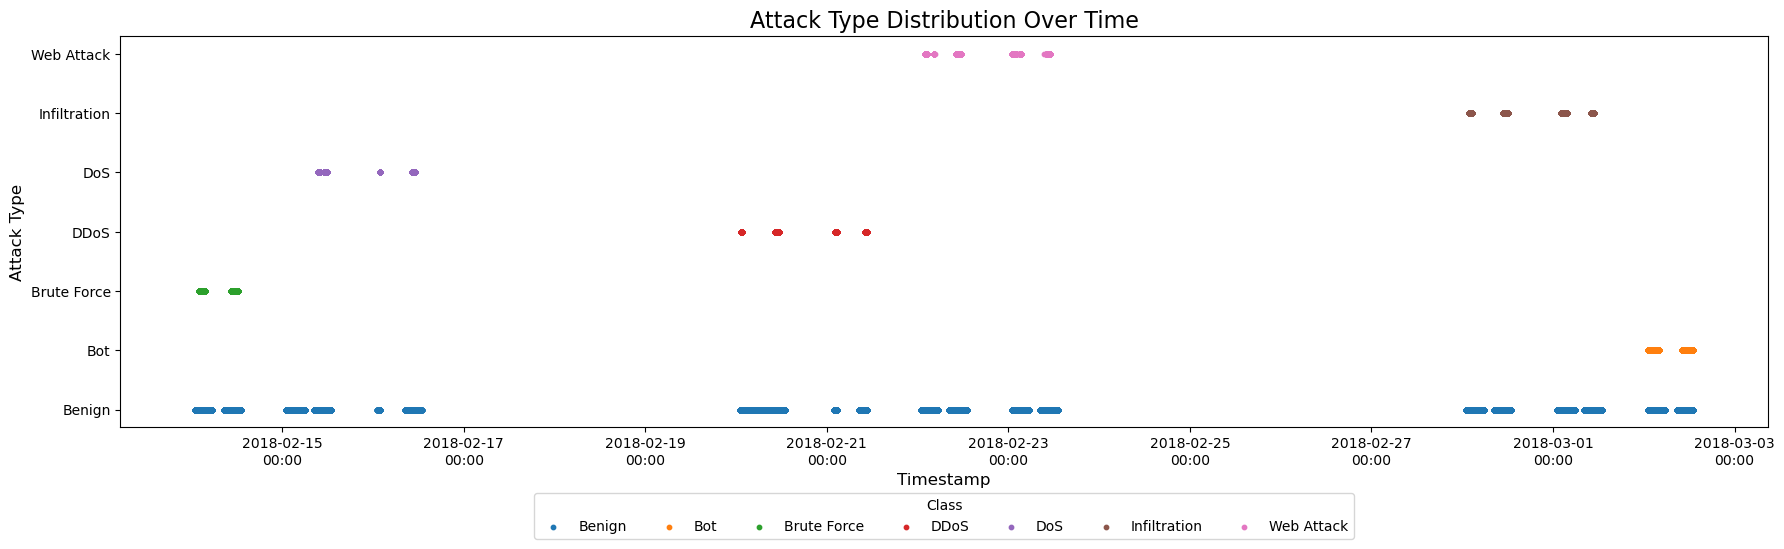

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Ensure Timestamp is datetime
df_combined['Timestamp'] = pd.to_datetime(df_combined['Timestamp'], errors='coerce', dayfirst=True)

# Sort by Timestamp
df_combined = df_combined.sort_values(by='Timestamp')

# Prepare figure
plt.figure(figsize=(18, 6))

# Plot each Attack_Type with a different color
for i, (label_name, group) in enumerate(df_combined.groupby('Attack_Type')):
    plt.scatter(group['Timestamp'], [label_name]*len(group), label=label_name, s=10)

# Title and labels
plt.title('Attack Type Distribution Over Time', fontsize=16)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Attack Type', fontsize=12)

# Format x-axis for dates
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
# plt.xticks(rotation=45, ha='right')

# Legend below plot, single row
plt.legend(
    title='Class',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=len(df_combined['Attack_Type'].unique()),  # all labels in one row
    fontsize=10
)

# Adjust layout to leave space for legend
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [30]:
# List attack types by day and intervals where attacks occurred.

import pandas as pd

# # ===== 1. Load your dataset =====
# csv_path = "D:/r6g/prog1/cicids2018/df_combine.csv"  # replace with your actual CSV
# df_combined = pd.read_csv(csv_path)

# Ensure Timestamp is datetime
df_combined['Timestamp'] = pd.to_datetime(df_combined['Timestamp'])

# Create a 'Date' column for daily grouping
df_combined['Date'] = df_combined['Timestamp'].dt.date

# ===== 2. Compute frequency of each attack type per day =====
attack_freq = df_combined.groupby(['Date', 'Attack_Type']).size().reset_index(name='Frequency')

# Pivot table for readability (optional)
attack_freq_pivot = attack_freq.pivot(index='Date', columns='Attack_Type', values='Frequency').fillna(0).astype(int)
print("Attack type frequency by day (pivot table):")
display(attack_freq_pivot)

# ===== 3. Compute start/end times and duration per attack type per day =====
attack_intervals = df_combined.groupby(['Date', 'Attack_Type'])['Timestamp'].agg(['min','max']).reset_index()
attack_intervals['Duration_seconds'] = (attack_intervals['max'] - attack_intervals['min']).dt.total_seconds()

print("Attack type intervals by day:")
display(attack_intervals)

# ===== 4. Combine frequency and intervals =====
attack_summary = pd.merge(attack_freq, attack_intervals, on=['Date','Attack_Type'])
attack_summary = attack_summary.rename(columns={
    'Frequency': 'Count',
    'min': 'Start_Time',
    'max': 'End_Time'
})

# Optional: percentage of the day
attack_summary['Percent_of_day'] = attack_summary['Duration_seconds'] / (24*3600) * 100

print("Combined attack summary per day:")
display(attack_summary)

# ===== 5. Optional: save to CSV =====
# attack_summary.to_csv("D:/r6g/prog1/cicids2018/attack_summary_by_day.csv", index=False)


Attack type frequency by day (pivot table):


Attack_Type,Benign,Bot,Brute Force,DDoS,DoS,Infiltration,Web Attack
Date,,,,,,,
2018-02-14,666268,0,156674,0,0,0,0
2018-02-15,994481,0,0,0,51740,0,0
2018-02-16,446772,0,0,0,464575,0,0
2018-02-20,7372555,0,0,576191,0,0,0
2018-02-21,360827,0,0,670194,0,0,0
2018-02-22,1044926,0,0,0,0,0,362
2018-02-23,1045797,0,0,0,0,0,566
2018-02-28,538125,0,0,0,0,68857,0
2018-03-01,237987,0,0,0,0,93040,0


Attack type intervals by day:


,Date,Attack_Type,min,max,Duration_seconds
0,2018-02-14,Benign,2018-02-14 01:00:00,2018-02-14 12:59:59,43199.0
1,2018-02-14,Brute Force,2018-02-14 02:01:21,2018-02-14 12:10:31,36550.0
2,2018-02-15,Benign,2018-02-15 01:00:00,2018-02-15 12:59:59,43199.0
3,2018-02-15,DoS,2018-02-15 09:27:42,2018-02-15 11:42:01,8059.0
4,2018-02-16,Benign,2018-02-16 01:00:32,2018-02-16 12:58:24,43072.0
5,2018-02-16,DoS,2018-02-16 01:45:27,2018-02-16 10:58:08,33161.0
6,2018-02-20,Benign,2018-02-20 01:00:00,2018-02-20 12:59:59,43199.0
7,2018-02-20,DDoS,2018-02-20 01:14:17,2018-02-20 11:16:48,36151.0
8,2018-02-21,Benign,2018-02-21 01:55:46,2018-02-21 10:43:21,31655.0
9,2018-02-21,DDoS,2018-02-21 02:11:08,2018-02-21 10:43:16,30728.0


Combined attack summary per day:


,Date,Attack_Type,Count,Start_Time,End_Time,Duration_seconds,Percent_of_day
0,2018-02-14,Benign,666268,2018-02-14 01:00:00,2018-02-14 12:59:59,43199.0,49.998843
1,2018-02-14,Brute Force,156674,2018-02-14 02:01:21,2018-02-14 12:10:31,36550.0,42.303241
2,2018-02-15,Benign,994481,2018-02-15 01:00:00,2018-02-15 12:59:59,43199.0,49.998843
3,2018-02-15,DoS,51740,2018-02-15 09:27:42,2018-02-15 11:42:01,8059.0,9.327546
4,2018-02-16,Benign,446772,2018-02-16 01:00:32,2018-02-16 12:58:24,43072.0,49.851852
5,2018-02-16,DoS,464575,2018-02-16 01:45:27,2018-02-16 10:58:08,33161.0,38.380787
6,2018-02-20,Benign,7372555,2018-02-20 01:00:00,2018-02-20 12:59:59,43199.0,49.998843
7,2018-02-20,DDoS,576191,2018-02-20 01:14:17,2018-02-20 11:16:48,36151.0,41.841435
8,2018-02-21,Benign,360827,2018-02-21 01:55:46,2018-02-21 10:43:21,31655.0,36.637731
9,2018-02-21,DDoS,670194,2018-02-21 02:11:08,2018-02-21 10:43:16,30728.0,35.564815


In [31]:
# ==========================================================
# Data Splitting starts here (70:15:15, floored by minute) except Web Attack
# ==========================================================

# Ensure Timestamp is datetime
df_combined['Timestamp'] = pd.to_datetime(df_combined['Timestamp'], errors='coerce', dayfirst=True)
df_combined = df_combined.sort_values(by='Timestamp').reset_index(drop=True)

train_list, val_list, test_list = [], [], []

# Get unique days in the dataset
unique_days = df_combined['Timestamp'].dt.date.unique()

for day in unique_days:
    # Filter data for the day
    df_day = df_combined[df_combined['Timestamp'].dt.date == day].sort_values(by='Timestamp')
    n = len(df_day)
    if n == 0:
        continue  # skip empty days

    # --- Adjust split ratios for specific days ---
    if str(day) in ["2018-02-22", "2018-02-23"]:
        train_end = int(0.67 * n)
        val_end = int(0.74 * n)
    else:
        train_end = int(0.7 * n)
        val_end = int(0.85 * n)
        
    # --- NEW: Floor the boundary timestamps to the nearest full minute ---
    train_bound_time = df_day.iloc[train_end - 1]['Timestamp'].floor('min')
    val_bound_time = df_day.iloc[val_end - 1]['Timestamp'].floor('min')

    # --- Adjust splits based on floored times ---
    train_split = df_day[df_day['Timestamp'] <= train_bound_time]
    val_split = df_day[(df_day['Timestamp'] > train_bound_time) & (df_day['Timestamp'] <= val_bound_time)]
    test_split = df_day[df_day['Timestamp'] > val_bound_time]

    train_list.append(train_split)
    val_list.append(val_split)
    test_list.append(test_split)

# Combine all days
train_df = pd.concat(train_list).reset_index(drop=True)
val_df = pd.concat(val_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)

print(f"Total Training records: {len(train_df)}")
print(f"Total Validation records: {len(val_df)}")
print(f"Total Test records: {len(test_df)}")


Total Training records: 10758441
Total Validation records: 2339258
Total Test records: 2735354


In [32]:
distribution_table = pd.DataFrame({
    'Training': train_df['Attack_Type'].value_counts(),
    'Validation': val_df['Attack_Type'].value_counts(),
    'Test': test_df['Attack_Type'].value_counts()
}).fillna(0).astype(int)  # fill missing classes with 0

print("Distribution of Attack_Type across datasets (counts):")
print(distribution_table)


Distribution of Attack_Type across datasets (counts):
              Training  Validation     Test
Attack_Type                                
Benign         9473180     1551279  2444085
Bot             156844       79483    45983
Brute Force     123302       21358    12014
DDoS            667693      487548    91144
DoS             253493      138443   124379
Infiltration     83442       60839    17616
Web Attack         487         308      133


In [34]:
# Calculate percentages for each set
distribution_percent = pd.DataFrame({
    'Training (%)': train_df['Attack_Type'].value_counts(normalize=True) * 100,
    'Validation (%)': val_df['Attack_Type'].value_counts(normalize=True) * 100,
    'Test (%)': test_df['Attack_Type'].value_counts(normalize=True) * 100
}).fillna(0).round(2)

print("Distribution of Attack_Type across datasets (percentages):")
print(distribution_percent)


Distribution of Attack_Type across datasets (percentages):
              Training (%)  Validation (%)  Test (%)
Attack_Type                                         
Benign               88.05           66.32     89.35
Bot                   1.46            3.40      1.68
Brute Force           1.15            0.91      0.44
DDoS                  6.21           20.84      3.33
DoS                   2.36            5.92      4.55
Infiltration          0.78            2.60      0.64
Web Attack            0.00            0.01      0.00


In [35]:
# Calculate percentages normalized by rows
import pandas as pd

# Get all attack types across all sets
all_attack_types = sorted(
    set(train_df['Attack_Type']).union(val_df['Attack_Type']).union(test_df['Attack_Type'])
)

# Calculate raw percentages per dataset
distribution_percent = pd.DataFrame({
    'Training': train_df['Attack_Type'].value_counts(),
    'Validation': val_df['Attack_Type'].value_counts(),
    'Test': test_df['Attack_Type'].value_counts()
}).reindex(all_attack_types).fillna(0)

# Normalize by row to sum 100%
distribution_percent = distribution_percent.div(distribution_percent.sum(axis=1), axis=0) * 100
distribution_percent = distribution_percent.round(2)

print("Distribution of Attack_Type across datasets (row sums = 100%):")
display(distribution_percent)


Distribution of Attack_Type across datasets (row sums = 100%):


,Training,Validation,Test
Attack_Type,,,
Benign,70.34,11.52,18.15
Bot,55.56,28.15,16.29
Brute Force,78.70,13.63,7.67
DDoS,53.57,39.12,7.31
DoS,49.10,26.81,24.09
Infiltration,51.54,37.58,10.88
Web Attack,52.48,33.19,14.33


In [36]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_time_series(df, timestamp_col='Timestamp', label_col='Attack_Type', figsize=(18,6), point_size=10):
    """
    Plots a time series scatter plot of labels over timestamps.

    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        timestamp_col (str): Name of the timestamp column.
        label_col (str): Name of the label column.
        figsize (tuple): Figure size.
        point_size (int): Size of scatter points.
    """
    # Ensure timestamp column is datetime
    df = df.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce', dayfirst=True)

    # Sort by timestamp
    df = df.sort_values(by=timestamp_col)

    # Prepare figure
    plt.figure(figsize=figsize)

    # Plot each label class with a different color
    for i, (label_name, group) in enumerate(df.groupby(label_col)):
        plt.scatter(group[timestamp_col], [label_name]*len(group), label=label_name, s=point_size)

    # Title and axis labels
    plt.title(f'{label_col} Distribution Over Time', fontsize=16)
    plt.xlabel('Timestamp', fontsize=12)
    plt.ylabel(label_col, fontsize=12)

    # Format x-axis dates
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
    # plt.xticks(rotation=45, ha='right')

    # Legend below plot in a single row
    plt.legend(
        title='Class',
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=len(df[label_col].unique()),
        fontsize=10
    )

    # Adjust layout to leave space for legend
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


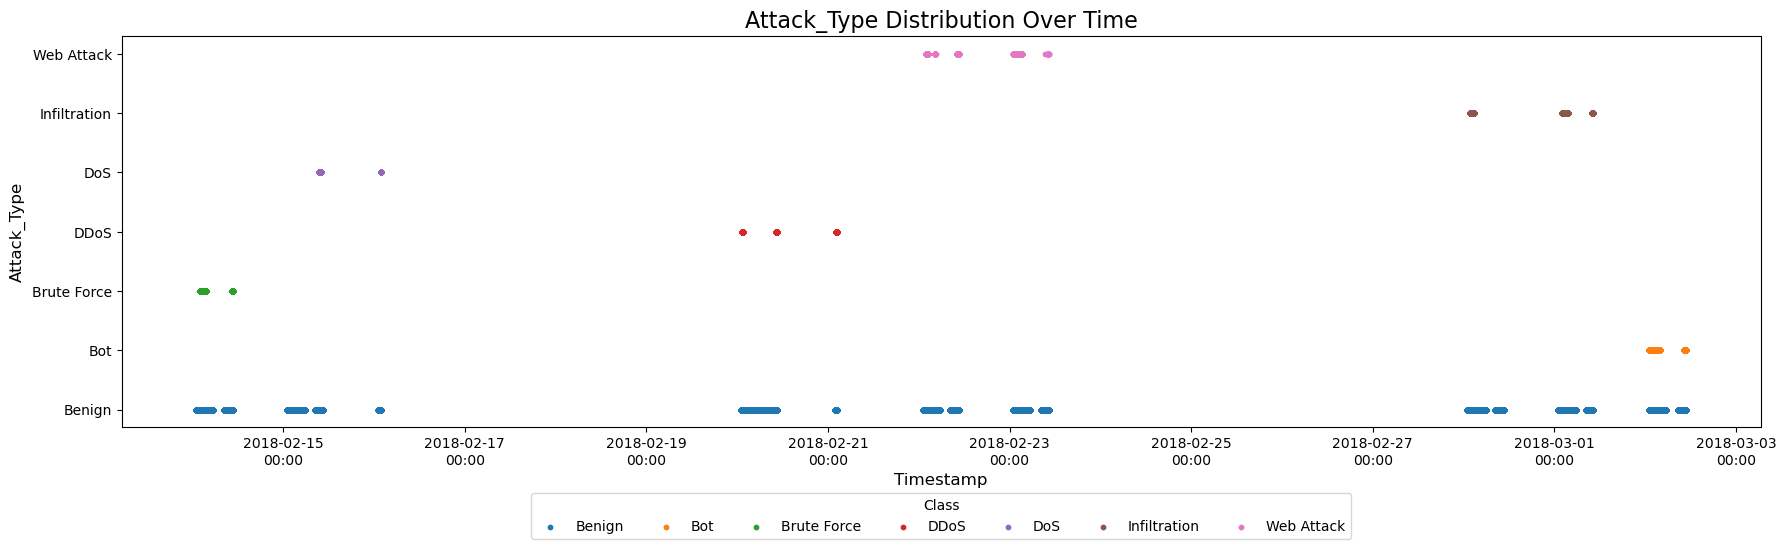

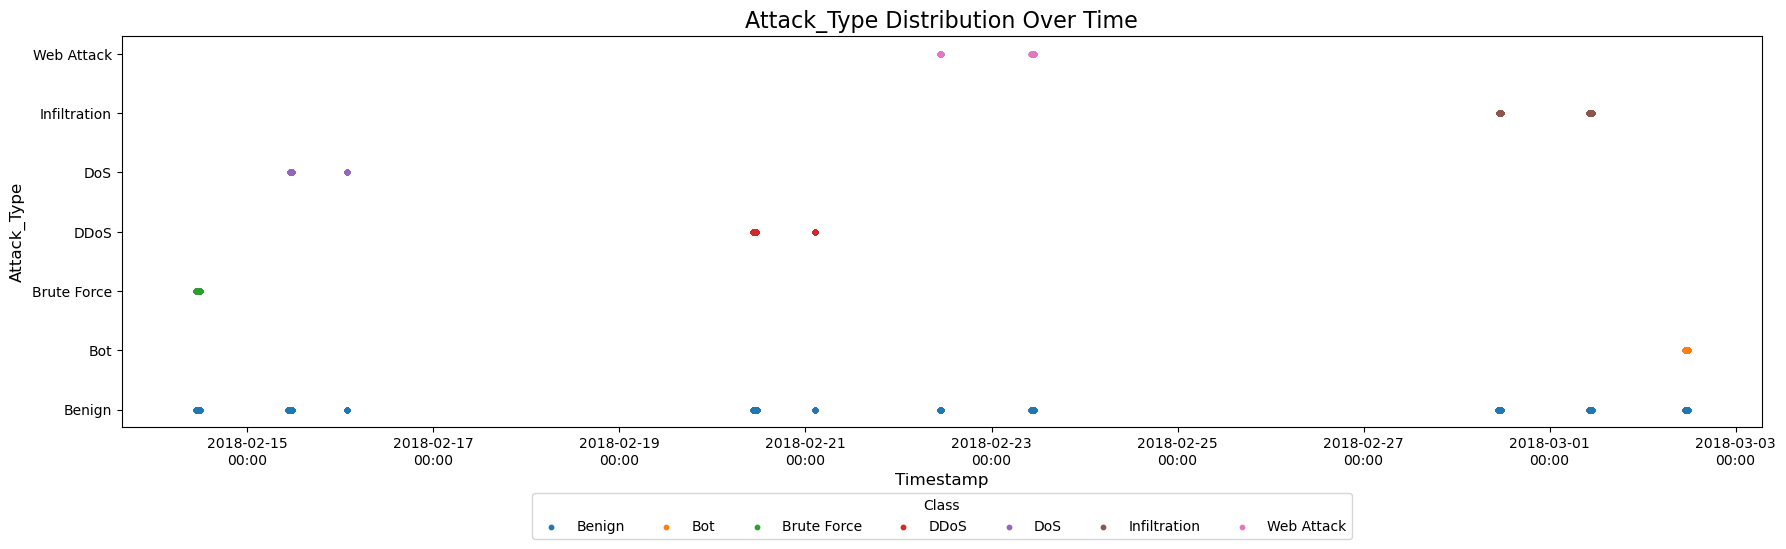

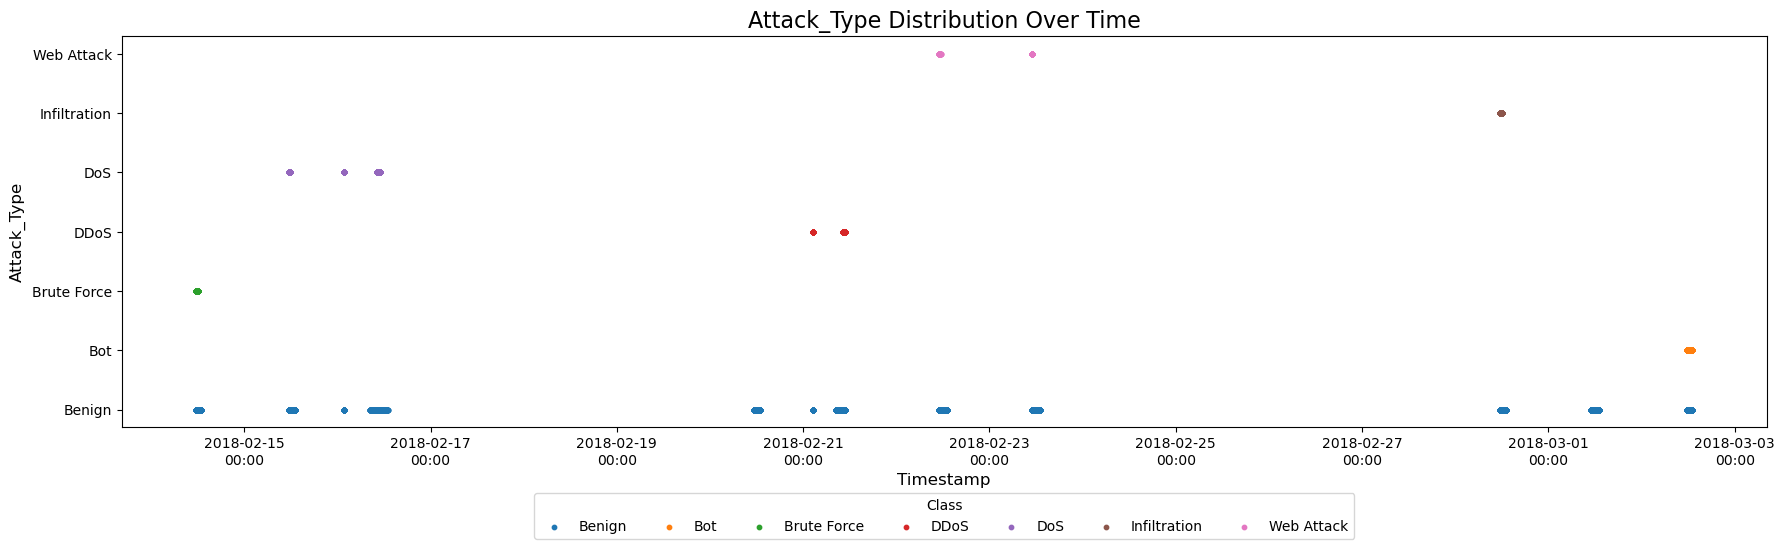

In [37]:
plot_time_series(train_df)
plot_time_series(val_df)
plot_time_series(test_df)


In [39]:
# Save Training set
train_df.to_csv(r'D:\fypadpm\dataset\CSECICIDS2018\df_train_setm.csv', index=False)

# Save Validation set
val_df.to_csv(r'D:\fypadpm\dataset\CSECICIDS2018\df_validation_setm.csv', index=False)

# Save Test set
test_df.to_csv(r'D:\fypadpm\dataset\CSECICIDS2018\df_test_setm.csv', index=False)

print("✅ Training, Validation, and Test sets saved successfully.")


✅ Training, Validation, and Test sets saved successfully.


#### Create Future Attack_Types

#### Flow Byts/s

In [29]:
null_count = df_combined['Flow Byts/s'].isnull().sum()
print("Number of null values in 'Flow Byts/s':", null_count) 

Number of null values in 'Flow Byts/s': 58449


In [21]:
pd.Categorical(df_combined['Flow Byts/s'])
# Before that there's mixed data type (numbers and string), so datatype is object.

['30597.30523', '135231.3167', '41501.0864', '0.0', '27100.60726', ..., '0', '0', '0', '0', '0']
Length: 15828303
Categories (7058825, object): ['0', '0.0', '0.008333524', '0.0083345468', ..., '99993.7589714785', '99998.9826128537', 'Infinity', 'inf']

In [22]:
# Convert column to numeric
df_combined['Flow Byts/s'] = pd.to_numeric(df_combined['Flow Byts/s'], errors='coerce')

C:\Users\fypadpm\AppData\Local\Temp\ipykernel_19744\3854011711.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Log Flow Byts/s'] = np.log(df_filtered['Flow Byts/s'] + 1)


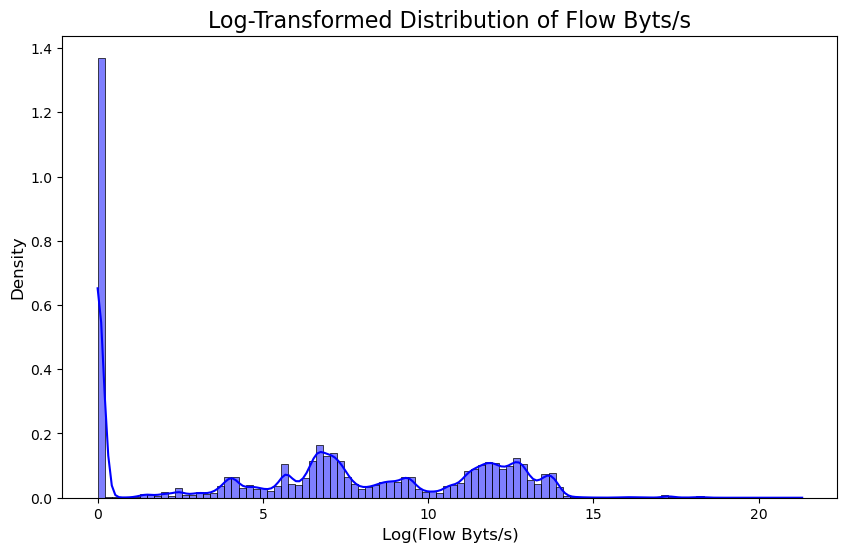

In [51]:
## Before replacing
df_filtered = df_combined[df_combined['Flow Byts/s'].notnull()] 

# Apply log transformation to 'Flow Byts/s', add a small constant to avoid log(0)
df_filtered['Log Flow Byts/s'] = np.log(df_filtered['Flow Byts/s'] + 1)

plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['Log Flow Byts/s'], bins=100, kde=True, color='blue', stat='density')

plt.title('Log-Transformed Distribution of Flow Byts/s', fontsize=16)
plt.xlabel('Log(Flow Byts/s)', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.show()

In [49]:
null_count = df_combined['Flow Byts/s'].isnull().sum()
print("Number of null values in 'Flow Byts/s':", null_count) 

Number of null values in 'Flow Byts/s': 58449


In [31]:
# Count occurrences of infinity, -infinity, and 0 before replacement
inf_count = df_combined['Flow Byts/s'].isin([np.inf, -np.inf]).sum()
zero_count = (df_combined['Flow Byts/s'] == 0).sum()
zero_str_count = (df_combined['Flow Byts/s'] == '0').sum()

print(f"Number of infinities: {inf_count}")
print(f"Number of zeros: {zero_count}")
print(f"Number of '0' strings: {zero_str_count}")

Number of infinities: 36005
Number of zeros: 4564375
Number of '0' strings: 0


In [69]:
# Identify rows where 'Flow Byts/s' is 0 and replace 0 with NaN
#zero_rows = df_combined[df_combined['Flow Byts/s'] == 0].index
#df_combined.loc[zero_rows, 'Flow Byts/s'] = np.nan

In [33]:
# Calculate medium of each column grouped by attack type without considering infinity and null values
medians_grouped = df_combined.groupby('Attack_Type')['Flow Byts/s'].apply(lambda x: x[~x.isin([np.inf, -np.inf, np.nan])].median())
print("Median of 'Flow Byts/s' for each Attack Type excluding NaN and infinity:")
print(medians_grouped)

Median of 'Flow Byts/s' for each Attack Type excluding NaN and infinity:
Attack_Type
Benign           1162.208891
Bot              9495.395238
Brute Force     11760.143893
DDoS                0.000000
DoS                 0.000000
Infiltration      773.160480
Web Attack         33.527227
Name: Flow Byts/s, dtype: float64


In [35]:
# Replace missing values with median based on attack type
def replace_null(row):
    if pd.isnull(row['Flow Byts/s']):
        return medians_grouped.get(row['Attack_Type'], np.nan)
    else:
        return row['Flow Byts/s']

df_combined['Flow Byts/s'] = df_combined.apply(replace_null, axis=1)

In [37]:
# Check max value and replace inf with max value
max_value = df_combined[df_combined['Flow Byts/s'] != np.inf]['Flow Byts/s'].max()
print(max_value)
df_combined['Flow Byts/s'] = df_combined['Flow Byts/s'].replace(np.inf, max_value)

# Replace -inf with 0
df_combined['Flow Byts/s'] = df_combined['Flow Byts/s'].replace(-np.inf, 0)

1806642857.14286


In [39]:
null_count = df_combined['Flow Byts/s'].isnull().sum()
print("Number of null values in 'Flow Byts/s':", null_count) 

Number of null values in 'Flow Byts/s': 0


In [41]:
# Count occurrences of infinity, -infinity, and 0 before replacement
inf_count = df_combined['Flow Byts/s'].isin([np.inf, -np.inf]).sum()
zero_count = (df_combined['Flow Byts/s'] == 0).sum()
zero_str_count = (df_combined['Flow Byts/s'] == '0').sum()

print(f"Number of infinities: {inf_count}")
print(f"Number of zeros: {zero_count}")
print(f"Number of '0' strings: {zero_str_count}")

## zeros exists due to -inf being replaced with 0

Number of infinities: 0
Number of zeros: 4564375
Number of '0' strings: 0


In [43]:
pd.Categorical(df_combined['Flow Byts/s'])
# After that datatype become float64

[30597.30523, 135231.31670, 41501.08640, 0.00000, 27100.60726, ..., 0.0, 0.0, 0.0, 0.0, 0.0]
Length: 15828303
Categories (7058098, float64): [0.000000, 0.008334, 0.008335, 0.008347, ..., 1.469750e+09, 1.618000e+09, 1.686000e+09, 1.806643e+09]

In [44]:
print(df_combined['Flow Byts/s'].dtype)

float64


### Convert data type of object to numerical

In [47]:
string_cols = df_combined.select_dtypes(include=['object'])

In [48]:
# Try converting string columns to numeric except 'Protocol' column
for col in string_cols.columns:
    if col != 'Protocol':
        try:
            df_combined[col] = pd.to_numeric(df_combined[col])
        except:
            print(f"Error converting column {col} to numeric. Skipping.")
    else:
        print(f"Skipping column {col} as it's excluded.")

Skipping column Protocol as it's excluded.
Error converting column Timestamp to numeric. Skipping.
Error converting column Label to numeric. Skipping.
Error converting column Flow ID to numeric. Skipping.
Error converting column Src IP to numeric. Skipping.
Error converting column Dst IP to numeric. Skipping.
Error converting column Attack_Type to numeric. Skipping.


In [51]:
df_combined['Timestamp'] = pd.to_datetime(df_combined['Timestamp'], dayfirst=True)
df_combined['Timestamp'] = df_combined['Timestamp'].apply(lambda x: x.timestamp())

In [52]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15828303 entries, 0 to 16233001
Data columns (total 85 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Dst Port           int64  
 1   Protocol           object 
 2   Timestamp          float64
 3   Flow Duration      int64  
 4   Tot Fwd Pkts       int64  
 5   Tot Bwd Pkts       int64  
 6   TotLen Fwd Pkts    float64
 7   TotLen Bwd Pkts    float64
 8   Fwd Pkt Len Max    float64
 9   Fwd Pkt Len Min    float64
 10  Fwd Pkt Len Mean   float64
 11  Fwd Pkt Len Std    float64
 12  Bwd Pkt Len Max    float64
 13  Bwd Pkt Len Min    float64
 14  Bwd Pkt Len Mean   float64
 15  Bwd Pkt Len Std    float64
 16  Flow Byts/s        float64
 17  Flow Pkts/s        float64
 18  Flow IAT Mean      float64
 19  Flow IAT Std       float64
 20  Flow IAT Max       float64
 21  Flow IAT Min       float64
 22  Fwd IAT Tot        float64
 23  Fwd IAT Mean       float64
 24  Fwd IAT Std        float64
 25  Fwd IAT Max        fl

In [85]:
# Check range of every column
# Select only numerical columns
numerical_cols = df_combined.select_dtypes(include=['number'])

# Calculate the range for each numerical column
range_summary = numerical_cols.describe().loc[['min', 'max']]

print("Range (min and max) of each numerical column:")
print(range_summary)

Range (min and max) of each numerical column:
     Dst Port     Timestamp  Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  \
min       0.0  3.564770e+05  -9.190110e+11           1.0           0.0   
max   65535.0  1.519996e+09   1.200000e+08      309629.0      123118.0   

     TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  Fwd Pkt Len Min  \
min              0.0              0.0              0.0              0.0   
max      144391846.0      156360426.0          64440.0           1460.0   

     Fwd Pkt Len Mean  ...  Fwd Seg Size Min  Active Mean    Active Std  \
min           0.00000  ...               0.0          0.0  0.000000e+00   
max       16529.31384  ...              56.0  114000000.0  7.523241e+07   

      Active Max   Active Min     Idle Mean      Idle Std      Idle Max  \
min          0.0          0.0  0.000000e+00  0.000000e+00  0.000000e+00   
max  114000000.0  114000000.0  3.955714e+11  2.622479e+11  9.797810e+11   

         Idle Min  Src Port  
min  0.000000e+00      

In [55]:
# Check if any column contains negative values
numerical_cols = df_combined.select_dtypes(include=['number'])

negative_values_sum = (numerical_cols < 0).sum()
negative_columns = negative_values_sum[negative_values_sum > 0]
print("Columns with negative values:")
print(negative_columns)

Columns with negative values:
Flow Duration             14
Flow Pkts/s               14
Flow IAT Mean             14
Flow IAT Max               3
Flow IAT Min              15
Fwd IAT Tot               14
Fwd IAT Mean              14
Fwd IAT Max                3
Fwd IAT Min               15
Init Fwd Win Byts    4432180
Init Bwd Win Byts    8192967
dtype: int64


In [57]:
# Replace abnormal negative values with median grouped by attack type
negative_columns = ['Flow Duration', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Max', 
                    'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Max', 'Fwd IAT Min']

for column in negative_columns:
    medians_grouped = df_combined[df_combined[column] >= 0].groupby('Attack_Type')[column].median().to_dict()
    
    df_combined[column] = np.where(
        df_combined[column] < 0,  
        df_combined['Attack_Type'].map(medians_grouped),  
        df_combined[column] 
    )

In [59]:
negative_values_after_replacement = (df_combined[negative_columns] < 0).sum()
print("Negative values after replacement:")
print(negative_values_after_replacement)

Negative values after replacement:
Flow Duration    0
Flow Pkts/s      0
Flow IAT Mean    0
Flow IAT Max     0
Flow IAT Min     0
Fwd IAT Tot      0
Fwd IAT Mean     0
Fwd IAT Max      0
Fwd IAT Min      0
dtype: int64


In [61]:
# Can drop two of these columns, contain much negative values and not an important feature
numerical_cols = df_combined.select_dtypes(include=['number'])

negative_values_sum = (numerical_cols < 0).sum()
negative_columns = negative_values_sum[negative_values_sum > 0]
print("Columns with negative values (After):")
print(negative_columns)

Columns with negative values (After):
Init Fwd Win Byts    4432180
Init Bwd Win Byts    8192967
dtype: int64


In [62]:
# Many null values in these columns due to only one csv file contain these features
null_values = df_combined.isnull().sum()
null_values = null_values[null_values > 0]

print("Columns with null values:")
print(null_values)

Columns with null values:
Flow ID     7879557
Src IP      7879557
Src Port    7879557
Dst IP      7879557
dtype: int64


In [65]:
df_combined = df_combined.drop(columns=['Init Fwd Win Byts', 'Init Bwd Win Byts'])

In [66]:
df_combined = df_combined.drop(columns=['Flow ID', 'Src IP', 'Src Port', 'Dst IP'])

In [67]:
df_combined = df_combined.drop(columns=['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg'])

In [73]:
df_combined.shape

(15828303, 71)

In [77]:
# Count the number of zeros in each column
zeros_count = (df_combined == 0).sum()

# Calculate the percentage of zero values in each column
zero_percentage = (zeros_count / len(df_combined)) * 100

# Filter columns with more than 0 zeros
columns_with_zeros = zeros_count[zeros_count > 0]

# Display the number of zeros and their percentage
print("Zero values count per column:")
print(columns_with_zeros)
print("\nPercentage of zero values per column:")
print(zero_percentage[columns_with_zeros.index])  # Display percentage only for columns with zeros

Zero values count per column:
Dst Port             238318
Flow Duration         94454
Tot Bwd Pkts        4075197
TotLen Fwd Pkts     4628181
TotLen Bwd Pkts     5603046
                     ...   
Active Min         14201129
Idle Mean          13481095
Idle Std           14540669
Idle Max           13481095
Idle Min           13481095
Length: 64, dtype: int64

Percentage of zero values per column:
Dst Port            1.505645
Flow Duration       0.596741
Tot Bwd Pkts       25.746266
TotLen Fwd Pkts    29.239907
TotLen Bwd Pkts    35.398905
                     ...    
Active Min         89.719846
Idle Mean          85.170817
Idle Std           91.864990
Idle Max           85.170817
Idle Min           85.170817
Length: 64, dtype: float64


In [79]:
# Display all column names with zero values
print(columns_with_zeros.index.tolist())

['Dst Port', 'Flow Duration', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Fwd Act Data Pkts', 'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max', 'Active M

In [81]:
df_combined.to_csv('C:/Users/fypadpm/YX/CSE CIC IDS2018/df_combined3.csv', index=False)

## Others

### Mapping

In [5]:
mapping = {
    'Benign': 'Benign',
    'Bot': 'Bot',
    'DoS attacks-SlowHTTPTest': 'DoS',
    'DoS attacks-Hulk': 'DoS',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DDOS attack-LOIC-UDP': 'DDoS',
    'DDOS attack-HOIC': 'DDoS',
    'Infilteration': 'Infiltration',
    'Brute Force -Web': 'Web Attack',
    'Brute Force -XSS': 'Web Attack',
    'SQL Injection': 'Web Attack',
    'FTP-BruteForce': 'Brute Force',
    'SSH-Bruteforce': 'Brute Force'
}

In [7]:
df_combined['Attack_Type'] = df_combined['Label'].map(mapping)

In [8]:
df_combined.tail()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Flow ID,Src IP,Src Port,Dst IP,Attack_Type
16232997,23,6,28/02/2018 11:59:12,3,1,1,0,0,0,0,...,0,0,0,0,Infilteration,NaN,NaN,NaN,NaN,Infiltration
16232998,425,6,28/02/2018 10:50:04,2,1,1,0,0,0,0,...,0,0,0,0,Infilteration,NaN,NaN,NaN,NaN,Infiltration
16232999,445,6,28/02/2018 12:52:55,732728,2,2,0,0,0,0,...,0,0,0,0,Benign,NaN,NaN,NaN,NaN,Benign
16233000,23,6,28/02/2018 11:10:50,22,1,1,0,0,0,0,...,0,0,0,0,Infilteration,NaN,NaN,NaN,NaN,Infiltration
16233001,443,6,28/02/2018 11:12:18,2,1,1,0,0,0,0,...,0,0,0,0,Infilteration,NaN,NaN,NaN,NaN,Infiltration
